# US Accidents ML Model
## Authors: Austin McCutcheon Trevor Schmuckley
## Date Due: 04/12

### Summary:
We used data from the link below to build an ML model that would predict US accidents

https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


ID
Source
*Severity
*Start_Time
*End_Time
*Start_Lat
*Start_Lng
End_Lat
End_Lng
Distance(mi)
Description
*Street
*City
*County
*State
*Zipcode
*Country
Timezone
Airport_Code
-*Weather_Timestamp
*Temperature(F)
*Wind_Chill(F)
*Humidity(%)
*Pressure(in)
*Visibility(mi)
Wind_Direction
*Wind_Speed(mph)
*Precipitation(in)
-*Weather_Condition

(Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight)

In [1]:
import sklearn as skl
import numpy as np
from lark.parsers.earley_forest import ForestNode
import os
import pandas as pd
import kagglehub
# other imports

In [2]:
# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Dataset folder:", path)

# See what files are inside
print(os.listdir(path))

100%|██████████| 653M/653M [00:02<00:00, 234MB/s]

Extracting files...


Dataset folder: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13
['US_Accidents_March23.csv']


In [3]:
csv_path = os.path.join(path, "US_Accidents_March23.csv")

cols = [
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "Street",
    "City",
    "County",
    "State",
    "Zipcode",
    "Country",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df = pd.read_csv(csv_path, usecols=cols)
print(df.head())

   Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
0         3  2016-02-08 05:46:00  2016-02-08 11:00:00  39.865147 -84.058723   
1         2  2016-02-08 06:07:59  2016-02-08 06:37:59  39.928059 -82.831184   
2         2  2016-02-08 06:49:27  2016-02-08 07:19:27  39.063148 -84.032608   
3         3  2016-02-08 07:23:34  2016-02-08 07:53:34  39.747753 -84.205582   
4         2  2016-02-08 07:39:07  2016-02-08 08:09:07  39.627781 -84.188354   

                      Street          City      County State     Zipcode  \
0                     I-70 E        Dayton  Montgomery    OH       45424   
1                   Brice Rd  Reynoldsburg    Franklin    OH  43068-3402   
2             State Route 32  Williamsburg    Clermont    OH       45176   
3                     I-75 S        Dayton  Montgomery    OH       45417   
4  Miamisburg Centerville Rd        Dayton  Montgomery    OH       45459   

  Country  Temperature(F)  Wind_Chill(F)  Humidity(%)  Pressure(in) 

In [4]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(7728394, 18)
Severity               int64
Start_Time            object
End_Time              object
Start_Lat            float64
Start_Lng            float64
Street                object
City                  object
County                object
State                 object
Zipcode               object
Country               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
dtype: object
Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
Street                 10869
City                     253
County                     0
State                      0
Zipcode                 1915
Country                    0
Temperature(F)        163853
Wind_Chill(F)        1999019
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi) 

In [5]:
## Removing NaN:
df = df.dropna(axis=0, how= 'any')
print(df.head(10))

    Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
5          3  2016-02-08 07:44:26  2016-02-08 08:14:26  40.100590 -82.925194   
9          3  2016-02-08 08:10:04  2016-02-08 08:40:04  40.100590 -82.925194   
11         3  2016-02-08 08:21:27  2016-02-08 08:51:27  39.932709 -82.830910   
14         2  2016-02-08 08:39:43  2016-02-08 09:09:43  39.972038 -82.913521   
20         2  2016-02-08 10:11:15  2016-02-08 10:41:15  40.052509 -82.882332   
22         2  2016-02-08 11:53:19  2016-02-08 12:23:19  39.628288 -84.226151   
23         3  2016-02-08 12:00:00  2016-02-08 12:45:00  40.023487 -82.994888   
25         2  2016-02-08 12:41:08  2016-02-08 13:11:08  40.158024 -82.641762   
26         2  2016-02-08 12:52:05  2016-02-08 13:37:05  39.733219 -84.159653   
27         2  2016-02-08 14:24:48  2016-02-08 15:09:48  39.775303 -84.200523   

               Street          City      County State     Zipcode Country  \
5      Westerville Rd   Westerville    Fra

In [6]:
# Cleaning up data

## Time -> Hours only
# conversion to actual times rather than obj
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['hour'] = pd.to_datetime(df['Start_Time']).dt.hour
df['day_of_week'] = pd.to_datetime(df['Start_Time']).dt.dayofweek
df['month'] = pd.to_datetime(df['Start_Time']).dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# drop bad times (nanoseconds were appended sometimes)
df = df.dropna(subset=['Start_Time', 'End_Time'])

# rush hour checks (7-9 am and 4-6 pm)
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

In [7]:
# adjustments for lat/long to be INTs
df['lat_bin'] = (df['Start_Lat'] * 10).astype(int)
df['lng_bin'] = (df['Start_Lng'] * 10).astype(int)

In [8]:
# Screen out weather patterns and identify freezing conditions
df['bad_weather'] = (
        (df['Visibility(mi)'] < 5) |
        (df['Precipitation(in)'] > 0) |
        (df['Wind_Speed(mph)'] > 15)
).astype(int)
df['freezing'] = (df['Temperature(F)'] < 32).astype(int)

In [9]:
# sanity check
print(df.shape)

(4540252, 27)


In [10]:
df = df.drop(columns=[
    "Street",
    "Zipcode",
    "Country",
    "Start_Time",
    "End_Time",
    "City",
    "County"
])

In [11]:
#encoding categories
df = pd.get_dummies(df, columns=["State"], drop_first=True)

In [12]:
## training 60 / valid 20 / testing 20
from sklearn.model_selection import train_test_split

X = df.drop("Severity", axis=1)
y = df["Severity"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced" # adjustments for class imbalances like severity skewing
)

model_fit = model.fit(X_train, y_train)

In [14]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, average='weighted'))
print("Recall:", recall_score(y_val, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.09      0.80      0.17     12444
           2       0.92      0.65      0.77    757104
           3       0.33      0.55      0.41    116849
           4       0.14      0.47      0.22     21653

    accuracy                           0.64    908050
   macro avg       0.37      0.62      0.39    908050
weighted avg       0.82      0.64      0.70    908050

Accuracy: 0.6371895820714718
Precision: 0.8173384294344097
Recall: 0.6371895820714717
F1 Score: 0.6983045919071696


In [15]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(15))

month              0.115493
Start_Lng          0.106237
Start_Lat          0.104919
lng_bin            0.081213
hour               0.076276
lat_bin            0.072121
Pressure(in)       0.061628
Wind_Chill(F)      0.059229
Temperature(F)     0.057901
Humidity(%)        0.046146
Wind_Speed(mph)    0.030670
day_of_week        0.029416
Visibility(mi)     0.014525
State_CA           0.014489
is_rush_hour       0.013522
dtype: float64


In [16]:
## Random Forest - Predictions moving forwards

# hyperparameters
n_estimators=100
max_depth=20

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

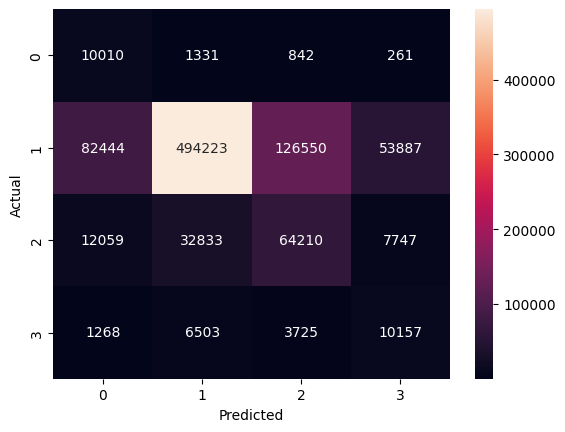

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Eval on test set:

y_test_pred = model_fit.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.10      0.81      0.17     12475
           2       0.92      0.65      0.76    756985
           3       0.33      0.55      0.41    116812
           4       0.14      0.47      0.22     21779

    accuracy                           0.64    908051
   macro avg       0.37      0.62      0.39    908051
weighted avg       0.82      0.64      0.70    908051



In [19]:
# comparing models:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print(classification_report(y_val, lr.predict(X_val)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.08      0.00      0.00     12444
           2       0.83      1.00      0.91    757104
           3       0.00      0.00      0.00    116849
           4       0.02      0.00      0.00     21653

    accuracy                           0.83    908050
   macro avg       0.23      0.25      0.23    908050
weighted avg       0.70      0.83      0.76    908050



In [20]:
## Permutation importance. This measures true performance against feature drops

from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_fit,
    X_val,
    y_val,
    n_repeats=2,
    random_state=42,
    n_jobs=1
)

perm_importance = pd.Series(result.importances_mean, index=X.columns)
print(perm_importance.sort_values(ascending=False).head(15))

State_PA        0.009134
State_IL        0.004630
State_NY        0.003598
State_NJ        0.002459
State_MD        0.002032
is_rush_hour    0.001965
State_VA        0.001405
hour            0.001220
State_MI        0.001191
State_OH        0.001135
State_LA        0.000862
State_MO        0.000755
State_WV        0.000731
State_DC        0.000675
State_TN        0.000672
dtype: float64
